In [21]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("stud.csv")

In [3]:
data.head(10)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [4]:
# Seperating dependent and independent variable
x= data.drop(['math_score'],axis=1)

In [5]:
x.head(10)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
5,female,group B,associate's degree,standard,none,83,78
6,female,group B,some college,standard,completed,95,92
7,male,group B,some college,free/reduced,none,43,39
8,male,group D,high school,free/reduced,completed,64,67
9,female,group B,high school,free/reduced,none,60,50


In [6]:
y=data['math_score']

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [12]:
categorical_feature=x.select_dtypes(include='str').columns
numerical_feature=x.select_dtypes(exclude='str').columns

In [14]:
print('Categorical Columns:',list(categorical_feature))
print('Numerical Columns:',list(numerical_feature))

Categorical Columns: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Numerical Columns: ['reading_score', 'writing_score']


In [15]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

oneHEncoder=OneHotEncoder()
scaler=StandardScaler()

ct=ColumnTransformer([('OneHEncoder',oneHEncoder,categorical_feature),('scaler',scaler,numerical_feature)])

In [16]:
x_train_tranformed=ct.fit_transform(x_train)

In [17]:
x_train_tranformed

array([[ 0.        ,  1.        ,  0.        , ...,  0.        ,
         0.86154402,  0.76641481],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.79091739,  0.69853042],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
        -0.12722883, -0.52338868],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.55098863, -1.06646383],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        -1.53976148, -1.06646383],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.49718371,  1.37737436]], shape=(700, 19))

In [18]:
x_test_transformed=ct.transform(x_test)

In [20]:
x_test_transformed

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.14405055,  1.03795239],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
        -0.2684821 ,  0.29122405],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.22590433,  0.22333966],
       ...,
       [ 0.        ,  1.        ,  1.        , ...,  1.        ,
        -0.76286852, -1.06646383],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
        -1.89289464, -2.01684535],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.35593045,  1.30948997]], shape=(300, 19))

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def eval_model(y_test,y_pred):
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    r2_square=r2_score(y_test,y_pred)
    rmse=np.sqrt(mse)
    return mae,rmse,r2_square

In [47]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [48]:
models = {
    'LinearRegressor':LinearRegression(),
    'SupportVectorRegressor':SVR(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'KNNRegressor':KNeighborsRegressor(),
    'RandomForestRegressor':RandomForestRegressor(),
    'CatBRegressor':CatBoostRegressor(),
    'XGBRegressor':XGBRegressor(),
    'Ridge':Ridge(),
    'Lasso':Lasso()
}

In [49]:
model_list=[]
r2_score_list=[]

In [50]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train_tranformed,y_train)
    y_train_pred=model.predict(x_train_tranformed)
    y_test_pred=model.predict(x_test_transformed)

    print('Model Name:',list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    mae_train,rmse_train,r2_square_train = eval_model(y_train,y_train_pred)
    print('Training Data Metrics')
    print("MAE:",mae_train)
    print("RMSE:",rmse_train)
    print("R2 Score:",r2_square_train)

    print('-'*40)

    mae_test,rmse_test,r2_square_test = eval_model(y_test,y_test_pred)
    print('Test Data Metrics')
    print("MAE:",mae_test)
    print("RMSE:",rmse_test)
    print("R2 Score:",r2_square_test)
    r2_score_list.append(r2_square_test)

    print("="*45)


Model Name: LinearRegressor
Training Data Metrics
MAE: 4.198519565142326
RMSE: 5.248303471123559
R2 Score: 0.8751313605993937
----------------------------------------
Test Data Metrics
MAE: 4.418261320297317
RMSE: 5.557570799195734
R2 Score: 0.8758630443016733
Model Name: SupportVectorRegressor
Training Data Metrics
MAE: 4.936842905948983
RMSE: 6.742700537503705
R2 Score: 0.793897507042227
----------------------------------------
Test Data Metrics
MAE: 5.714497799212186
RMSE: 8.23731837884098
R2 Score: 0.7272889176982609
Model Name: DecisionTreeRegressor
Training Data Metrics
MAE: 0.02142857142857143
RMSE: 0.2988071523335984
R2 Score: 0.9995952401013053
----------------------------------------
Test Data Metrics
MAE: 6.456666666666667
RMSE: 8.09135340965898
R2 Score: 0.7368681472870308
Model Name: KNNRegressor
Training Data Metrics
MAE: 4.422285714285715
RMSE: 5.573211436352089
R2 Score: 0.8591922559652381
----------------------------------------
Test Data Metrics
MAE: 5.65
RMSE: 7.2860

In [51]:
df_summary=pd.DataFrame(list(zip(model_list,r2_score_list)),columns=['Model','R2_Score']).sort_values(by='R2_Score',ascending=False)

In [52]:
df_summary

,Model,R2_Score
7,Ridge,0.875902
0,LinearRegressor,0.875863
5,CatBRegressor,0.852146
4,RandomForestRegressor,0.847193
6,XGBRegressor,0.811816
8,Lasso,0.810567
3,KNNRegressor,0.786640
2,DecisionTreeRegressor,0.736868
1,SupportVectorRegressor,0.727289


#### From the above summary we can see that Ridge Model performs best among other models with R2 Score of 87.5%

In [63]:
model_ridge = Ridge()
model_ridge.fit(x_train_tranformed,y_train)
y_pred_ridge = model_ridge.predict(x_test_transformed)

<Axes: ylabel='Count'>

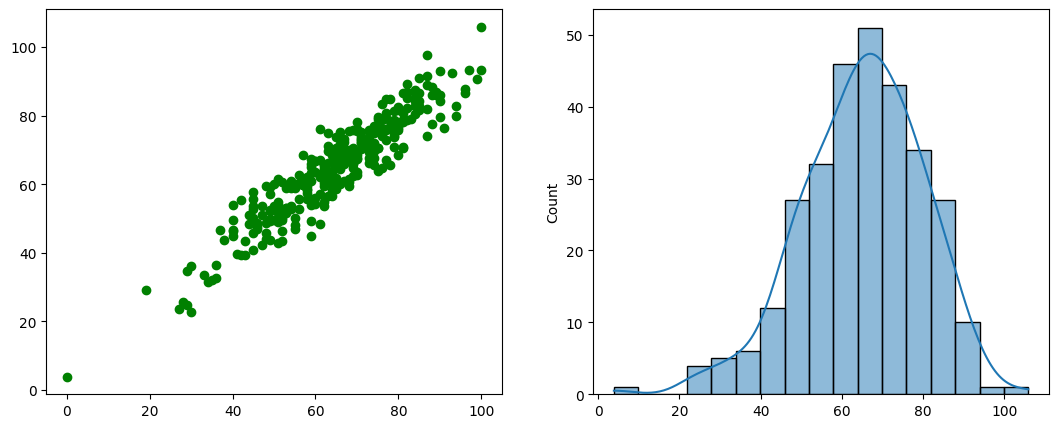

In [67]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,5))
plt.subplot(131)
plt.scatter(y_test,y_pred_ridge,color='g')

plt.subplot(132)
sns.histplot(y_pred_ridge,kde=True)



In [70]:
df_residuals=pd.DataFrame({'Actual':y_test,'Predicted':y_pred_ridge,'Residuals':y_test-y_pred_ridge}).sort_index()

In [72]:
df_residuals.head(10)

,Actual,Predicted,Residuals
2,90,84.428868,5.571132
3,47,51.107934,-4.107934
5,71,72.116999,-1.116999
7,40,44.852258,-4.852258
9,38,43.828195,-5.828195
10,58,58.673709,-0.673709
23,69,66.087516,2.912484
25,73,73.902782,-0.902782
29,62,64.633602,-2.633602
30,69,67.273287,1.726713


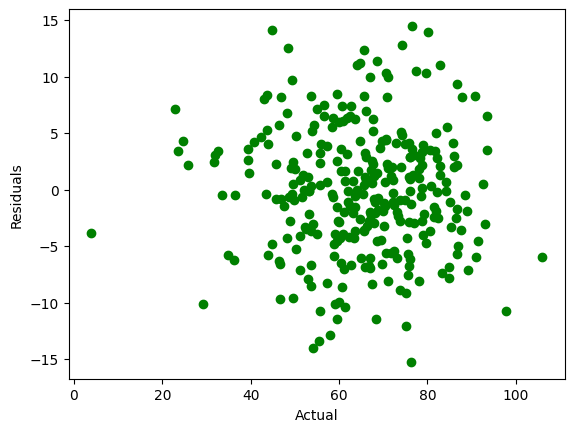

In [75]:
plt.scatter(df_residuals['Predicted'],df_residuals['Residuals'],color='g')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.show()